# PCA analysis (v2) for FtsQLBWI trajectories

This notebook follows the MDAnalysis PCA tutorial pattern:
- Load trajectories from the index CSV (no GUI)
- Align trajectory on a selection (typically protein backbone)
- Run PCA on the aligned coordinates
- Project frames into PC space and generate standard plots


In [37]:
# Parameters

import os
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
if (_cwd / 'src').is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / 'src').is_dir():
    REPO_ROOT = _cwd.parent
else:
    REPO_ROOT = Path(os.getenv('MD_REPO_ROOT', _cwd)).resolve()

SRC_DIR = REPO_ROOT / 'src'
if SRC_DIR.is_dir() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Index CSV
if 'MD_INDEX_CSV' in os.environ:
    INDEX_CSV = Path(os.environ['MD_INDEX_CSV']).expanduser().resolve()
else:
    _candidates = [
        Path(r'D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/FtsW Manuscript/Anton_SimulationIndex20260413.csv'),
        REPO_ROOT / 'data' / 'trajectory_index.csv',
    ]
    INDEX_CSV = next((p.resolve() for p in _candidates if p.exists()), _candidates[-1].resolve())

# Choose which simulation to analyze
SIM_TO_ANALYZE = os.getenv('MD_SIM_TO_ANALYZE', '58')

# Alignment / PCA selections
# Paper choice: backbone of all proteins (not just PROD)
ALIGN_SELECT = os.getenv('MD_ALIGN_SELECT', 'segid PROD and name CA')
PCA_SELECT = os.getenv('MD_PCA_SELECT', 'segid PROD and name CA')

# Performance
IN_MEMORY = False

# Output directory
OUT_ROOT = Path(os.getenv('MD_OUT_ROOT', INDEX_CSV.parent)).expanduser().resolve()
OUT_DIR = (OUT_ROOT / 'pca' / f'sim_{SIM_TO_ANALYZE}').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT: {REPO_ROOT}')
print(f'INDEX_CSV: {INDEX_CSV}')
print(f'SIM_TO_ANALYZE: {SIM_TO_ANALYZE}')
print(f'ALIGN_SELECT: {ALIGN_SELECT}')
print(f'PCA_SELECT: {PCA_SELECT}')
print(f'OUT_DIR: {OUT_DIR}')


REPO_ROOT: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics
INDEX_CSV: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\Anton_SimulationIndex20260413.csv
SIM_TO_ANALYZE: 58
ALIGN_SELECT: segid PROD and name CA
PCA_SELECT: segid PROD and name CA
OUT_DIR: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\pca\sim_58


In [38]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.analysis import align
from MDAnalysis.analysis import pca as mda_pca

from traj_utils import validate_traj_index, read_trajectories


In [39]:
# Load trajectory

valid_df = validate_traj_index(str(INDEX_CSV))
u_list, label_list, tf_list = read_trajectories(valid_df, [str(SIM_TO_ANALYZE)], in_memory=IN_MEMORY)
u = u_list[0]
sim_name = label_list[0]
time_factor = float(tf_list[0])

print(f'Loaded: {SIM_TO_ANALYZE} -> {sim_name}')
print(f'Frames: {len(u.trajectory)}')
print(f'time_factor (ns/frame): {time_factor}')


Missing system file (PSF): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/36_kpn_S1S3_Mg_310K/p000-004_p088-92_clean.pdb
Missing trajectory file (DCD): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/36_kpn_S1S3_Mg_310K/p000-004_p088-92_clean.dcd
Missing system file (PSF): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/37_ccr_S1S3_Mg_310K/p000-004_p096-100_clean.pdb
Missing trajectory file (DCD): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/37_ccr_S1S3_Mg_310K/p000-004_p096-100_clean.dcd
D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\Anton_SimulationIndex20260413.csv
reading: 58
58: 840 frames, 1008.0 ns
Loaded: 58 -> S130C S136 FtsN 
Frames: 840
time_factor (ns/frame): 1.2


In [40]:
# Align trajectory (tutorial step)
# This modifies the coordinates during the analysis run (in-memory if requested).

aligner = align.AlignTraj(u, u, select=ALIGN_SELECT, in_memory=IN_MEMORY).run()
print('Alignment done')


Alignment done


In [41]:
# Run PCA (tutorial step)

# Tip: PCA runtime scales strongly with number of atoms in `PCA_SELECT` and number of frames.
# If needed, reduce `n_components` or the selection.

pc = mda_pca.PCA(
    u,
    select=PCA_SELECT,
    align=False,
    mean=None,
    n_components=10,
).run()

ag = u.select_atoms(PCA_SELECT)
print(f'PCA selection atoms: {len(ag.atoms)}')
print(f'p_components shape: {pc.results.p_components.shape}')
print(f'PC1 variance: {pc.results.variance[0]:.5f}')
for i in range(min(5, len(pc.results.cumulated_variance))):
    print(f'Cumulative variance PC{i+1}: {pc.results.cumulated_variance[i]:.3f}')


PCA selection atoms: 369
p_components shape: (1107, 10)
PC1 variance: 164.91931
Cumulative variance PC1: 0.284
Cumulative variance PC2: 0.459
Cumulative variance PC3: 0.529
Cumulative variance PC4: 0.572
Cumulative variance PC5: 0.611


In [42]:
# Transform (project frames into PC space)

n_components = 3
transformed = pc.transform(ag, n_components=n_components)

df = pd.DataFrame(transformed, columns=[f'PC{i+1}' for i in range(n_components)])
df['Time (ns)'] = np.arange(len(df)) * time_factor

df.head()


,PC1,PC2,PC3,Time (ns)
0,-8.564488,5.130575,1.097142,0.0
1,-17.183536,9.054288,1.270108,1.2
2,-19.314485,28.432252,6.636508,2.4
3,-18.398359,26.652490,3.774733,3.6
4,-17.914561,28.095775,6.378380,4.8


In [43]:
# Visualize an individual principal component as structures / a mode trajectory
#
# This builds coordinates for the PCA selection only.
# You can load the written PDB(s) in PyMOL/VMD/ChimeraX, or view the multiframe PDB in a viewer.

PC_TO_VIEW = int(os.getenv('MD_PC_TO_VIEW', '1'))  # 1-based
MODE_SCALE = float(os.getenv('MD_MODE_SCALE', '3.0'))  # roughly 'how many std dev' to move along the mode
N_MODE_FRAMES = int(os.getenv('MD_MODE_FRAMES', '21'))

pc_vec = pc.results.p_components[:, PC_TO_VIEW - 1]  # shape (3*M,)

# Estimate a reasonable amplitude from the distribution of projections
pc_coord = transformed[:, PC_TO_VIEW - 1]
amplitude = MODE_SCALE * float(np.nanstd(pc_coord))

mean_flat = pc.mean.flatten()  # shape (3*M,)

coords_minus = (mean_flat - amplitude * pc_vec).reshape((-1, 3))
coords_plus = (mean_flat + amplitude * pc_vec).reshape((-1, 3))

# Write two endpoint structures (selection-only)
out_minus = OUT_DIR / f'pc{PC_TO_VIEW}_minus_{MODE_SCALE:.1f}sd.pdb'
out_plus = OUT_DIR / f'pc{PC_TO_VIEW}_plus_{MODE_SCALE:.1f}sd.pdb'

u_minus = mda.Merge(ag)
u_minus.atoms.positions = coords_minus
u_minus.atoms.write(str(out_minus))

u_plus = mda.Merge(ag)
u_plus.atoms.positions = coords_plus
u_plus.atoms.write(str(out_plus))

print(f'Wrote: {out_minus}')
print(f'Wrote: {out_plus}')

# Write an interpolated "mode trajectory" as a multiframe PDB
alphas = np.linspace(-amplitude, amplitude, N_MODE_FRAMES)
out_mode = OUT_DIR / f'pc{PC_TO_VIEW}_mode_{MODE_SCALE:.1f}sd_{N_MODE_FRAMES}frames.pdb'

u_mode = mda.Merge(ag)
with mda.Writer(str(out_mode), multiframe=True) as W:
    for a in alphas:
        u_mode.atoms.positions = (mean_flat + a * pc_vec).reshape((-1, 3))
        W.write(u_mode.atoms)

print(f'Wrote: {out_mode}')


c:\ProgramData\Anaconda3\envs\md-distance-analysis\Lib\site-packages\MDAnalysis\coordinates\PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
c:\ProgramData\Anaconda3\envs\md-distance-analysis\Lib\site-packages\MDAnalysis\coordinates\PDB.py:1282: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn(
c:\ProgramData\Anaconda3\envs\md-distance-analysis\Lib\site-packages\MDAnalysis\coordinates\PDB.py:1282: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn(
c:\ProgramData\Anaconda3\envs\md-distance-analysis\Lib\site-packages\MDAnalysis\coordinates\PDB.py:1282: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn(
c:\ProgramData\Anaconda3\envs\md-distance-analysis\Lib\site-packages\MDAnalysis\coordinates\PDB.py:1282: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.

Wrote: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\pca\sim_58\pc1_minus_3.0sd.pdb
Wrote: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\pca\sim_58\pc1_plus_3.0sd.pdb
Wrote: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\pca\sim_58\pc1_mode_3.0sd_21frames.pdb


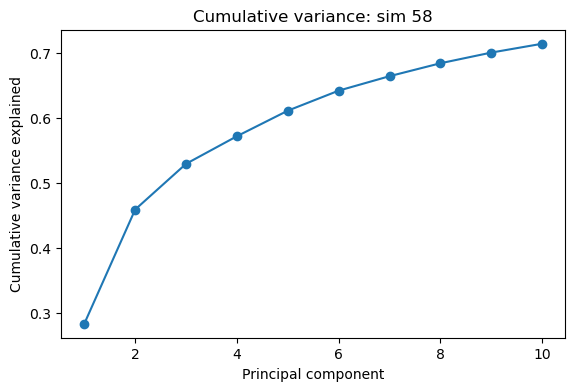

Wrote: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\pca\sim_58\cumulated_variance.png


In [44]:
# Plot: cumulative explained variance

cum = pc.results.cumulated_variance
n_show = min(20, len(cum))

plt.figure(figsize=(6.5, 4.0))
plt.plot(np.arange(1, n_show + 1), cum[:n_show], marker='o')
plt.xlabel('Principal component')
plt.ylabel('Cumulative variance explained')
plt.title(f'Cumulative variance: sim {SIM_TO_ANALYZE}')
out_png = OUT_DIR / 'cumulated_variance.png'
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
print(f'Wrote: {out_png}')


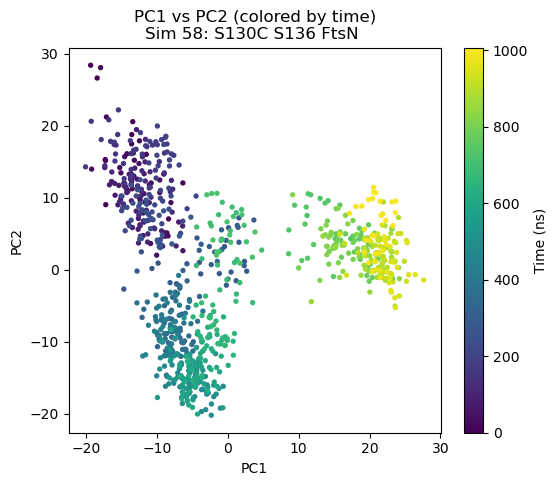

Wrote: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\pca\sim_58\pc1_pc2_time.png


In [45]:
# Plot: PC1 vs PC2 scatter colored by time

plt.figure(figsize=(6.0, 5.0))
sc = plt.scatter(df['PC1'], df['PC2'], c=df['Time (ns)'], s=8, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f"PC1 vs PC2 (colored by time)\nSim {SIM_TO_ANALYZE}: {sim_name}")
plt.colorbar(sc, label='Time (ns)')
out_png = OUT_DIR / 'pc1_pc2_time.png'
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
print(f'Wrote: {out_png}')


In [46]:
# (Optional) save the PC projections to CSV

out_csv = OUT_DIR / 'pca_projection.csv'
df.to_csv(out_csv, index=False)
print(f'Wrote: {out_csv}')


Wrote: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\pca\sim_58\pca_projection.csv
